# Round 1 — Agent EDA

**Products:** `ASH_COATED_OSMIUM`, `INTARIAN_PEPPER_ROOT`  
**Days covered:** -2, -1, 0  
**Goal:** Understand price dynamics, spread, order-book structure, and trade flow for both products — then derive fair-value estimates and strategy direction for `trader.py`.

---
**Sections:**
1. Setup & Data Loading
2. Price Overview
3. Spread Analysis
4. Order Book Depth
5. Trade Flow
6. Fair Value Estimation
7. Cumulative PnL Review
8. Summary Report

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR = '../data'
DAYS = [-2, -1, 0]
PRODUCTS = ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
DAY_COLORS = {-2: '#1f77b4', -1: '#ff7f0e', 0: '#2ca02c'}
PROD_COLORS = {'ASH_COATED_OSMIUM': '#e377c2', 'INTARIAN_PEPPER_ROOT': '#17becf'}

In [2]:
# ----- Load prices (all 3 days) -----
prices_frames = []
for day in DAYS:
    df = pd.read_csv(f'{DATA_DIR}/prices_round_1_day_{day}.csv', sep=';')
    prices_frames.append(df)
prices_all = pd.concat(prices_frames, ignore_index=True)

# Cross-day time index for continuous x-axis
prices_all['time_index'] = prices_all['day'] * 1_000_000 + prices_all['timestamp']

# Fill missing order-book volumes with 0
vol_cols = [c for c in prices_all.columns if 'volume' in c]
prices_all[vol_cols] = prices_all[vol_cols].fillna(0)

# Drop rows where mid_price == 0 (one-sided book / no quote)
prices_all = prices_all[prices_all['mid_price'] > 0].copy()

# ----- Load trades (all 3 days) — trades files have no 'day' column -----
trades_frames = []
for day in DAYS:
    df = pd.read_csv(f'{DATA_DIR}/trades_round_1_day_{day}.csv', sep=';')
    df['day'] = day
    trades_frames.append(df)
trades_all = pd.concat(trades_frames, ignore_index=True)
trades_all['time_index'] = trades_all['day'] * 1_000_000 + trades_all['timestamp']

print(f"Prices: {len(prices_all):,} rows after filtering")
print(f"  Products : {prices_all['product'].unique().tolist()}")
print(f"  Days     : {sorted(prices_all['day'].unique().tolist())}")
print(f"\nTrades: {len(trades_all):,} rows")
print(f"  Symbols  : {trades_all['symbol'].unique().tolist()}")
prices_all.head(3)

Prices: 59,897 rows after filtering
  Products : ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
  Days     : [-2, -1, 0]

Trades: 2,276 rows
  Symbols  : ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,time_index
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,0.0,NaN,0.0,10005.0,9.0,10008.0,17.0,NaN,0.0,9998.5,0.0,-2000000
1,-2,0,ASH_COATED_OSMIUM,NaN,0.0,NaN,0.0,NaN,0.0,10010.0,25.0,NaN,0.0,NaN,0.0,10010.0,0.0,-2000000
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,0.0,10006.0,11.0,10008.0,16.0,NaN,0.0,10000.5,0.0,-1999900


## Compute Useful Features

### Wall-Mid

In [3]:
# Compute wall mid
def computeWallMid(row):
    bids = [
        (row["bid_price_1"], row["bid_volume_1"]),
        (row["bid_price_2"], row["bid_volume_2"]),
        (row["bid_price_3"], row["bid_volume_3"])
    ]

    asks = [
        (row["ask_price_1"], row["ask_volume_1"]),
        (row["ask_price_2"], row["ask_volume_2"]),
        (row["ask_price_3"], row["ask_volume_3"])
    ]
    
    # exclude nans before passing to max function
    valid_bids = [(p,v) for p,v in bids if pd.notna(p) and v > 0]
    valid_asks = [(p,v) for p,v in asks if pd.notna(p) and v > 0]

    
    # if no valid quotes for either side, then return np.nan
    if not valid_bids or not valid_asks:
        return np.nan
    else:
        wall_bid = max(valid_bids, key = lambda x: x[1])[0]
        wall_ask = max(valid_asks, key = lambda x: x[1])[0]
        return (wall_bid + wall_ask)  / 2

# apply
prices_all["wall_mid"] = prices_all.apply(computeWallMid, axis = 1)

# fill na with mid price
prices_all["wall_mid"] = prices_all["wall_mid"].fillna(prices_all["mid_price"])
prices_all.head()
    

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,time_index,wall_mid
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,0.0,NaN,0.0,10005.0,9.0,10008.0,17.0,NaN,0.0,9998.5,0.0,-2000000,10000.0
1,-2,0,ASH_COATED_OSMIUM,NaN,0.0,NaN,0.0,NaN,0.0,10010.0,25.0,NaN,0.0,NaN,0.0,10010.0,0.0,-2000000,10010.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,0.0,10006.0,11.0,10008.0,16.0,NaN,0.0,10000.5,0.0,-1999900,10000.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,0.0,NaN,0.0,10008.0,15.0,10011.0,20.0,NaN,0.0,10000.0,0.0,-1999900,10001.5
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,0.0,NaN,0.0,10008.0,20.0,NaN,0.0,NaN,0.0,10001.5,0.0,-1999800,10001.5


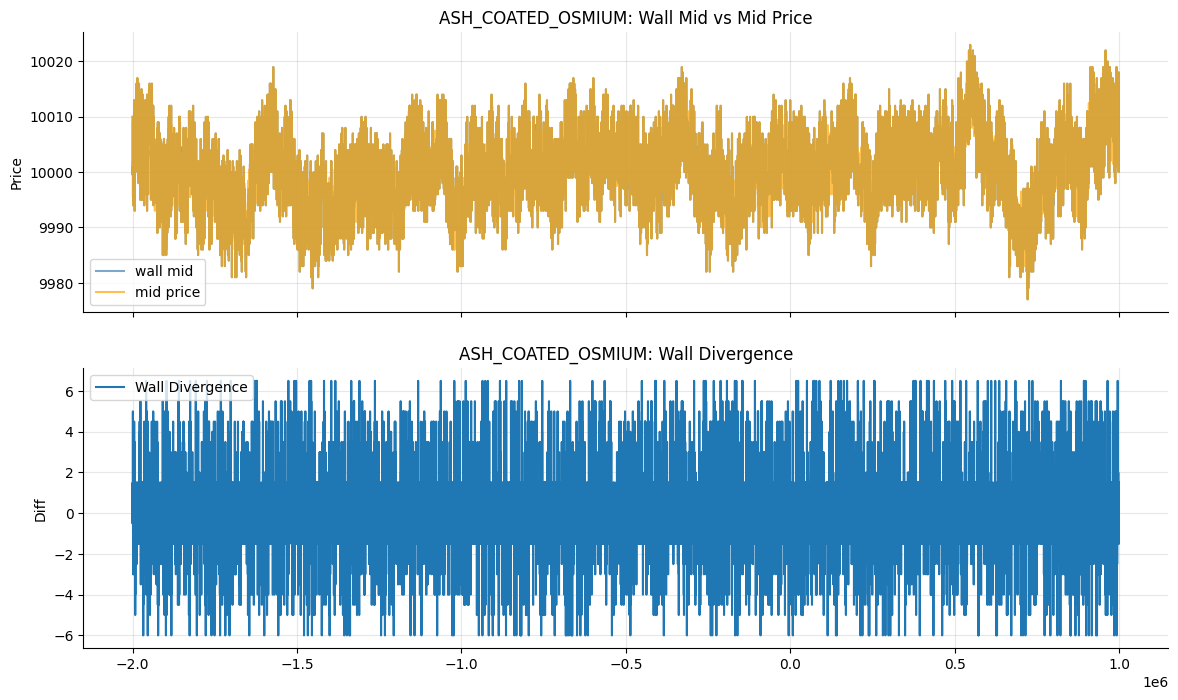

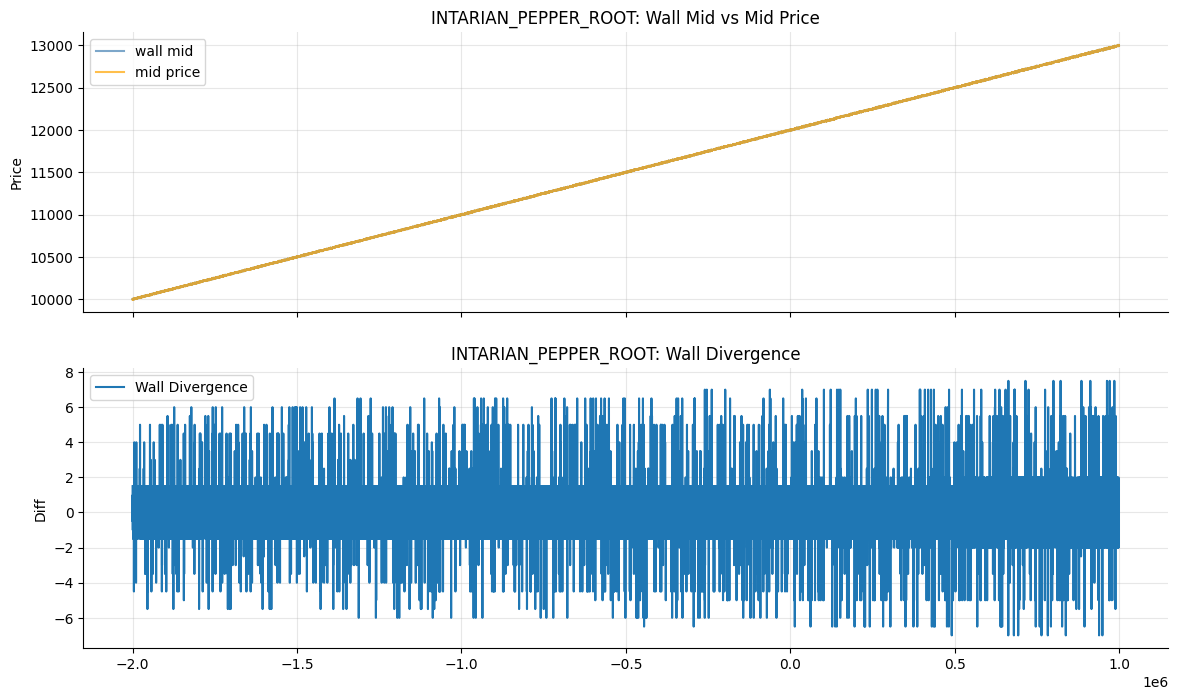

In [4]:
# compare 
for prod in PRODUCTS:
    p = prices_all[prices_all["product"]== prod]
    p["wall_div"] = p["wall_mid"] - p["mid_price"]

    # plot 
    fig, axes = plt.subplots(2,1, figsize = (14,8), sharex = True)
    axes[0].plot(p["time_index"], p["wall_mid"], label = "wall mid", alpha = 0.7, color = "steelblue")
    axes[0].plot(p["time_index"], p["mid_price"], label = "mid price", alpha = 0.7, color = "orange")
    axes[0].set_ylabel("Price")
    axes[0].legend()
    axes[0].set_title(f"{prod}: Wall Mid vs Mid Price")

    axes[1].plot(p["time_index"], p["wall_div"], label = "Wall Divergence")
    axes[1].set_ylabel("Diff")    
    axes[1].legend()
    axes[1].set_title(f"{prod}: Wall Divergence")

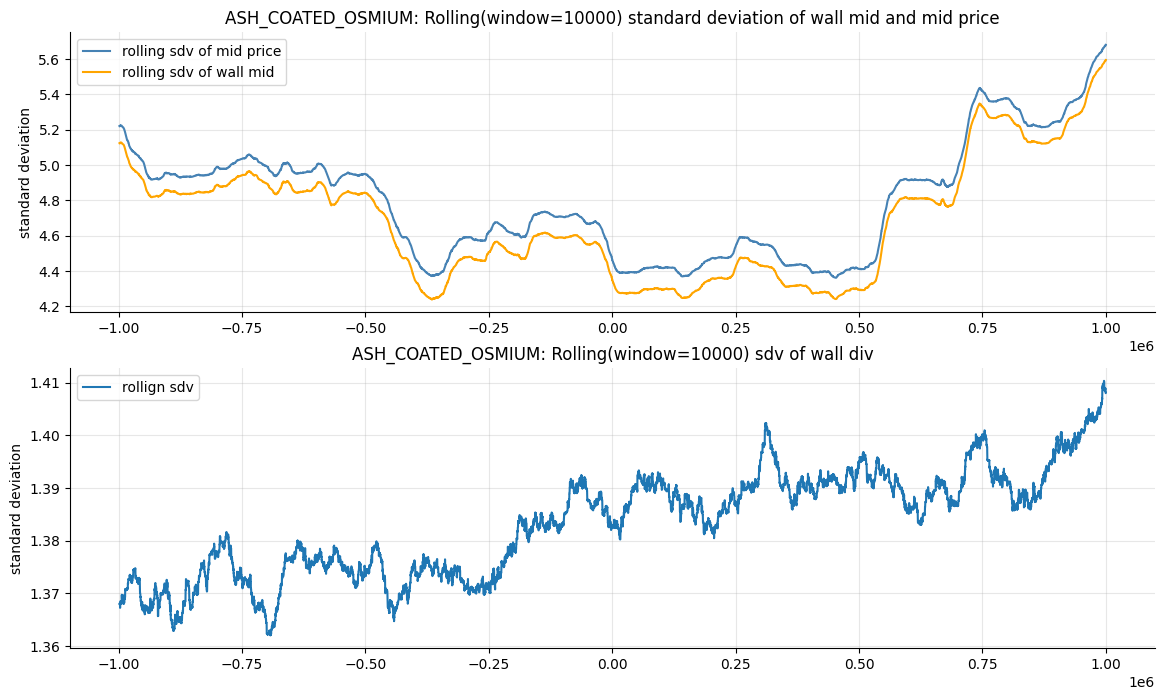

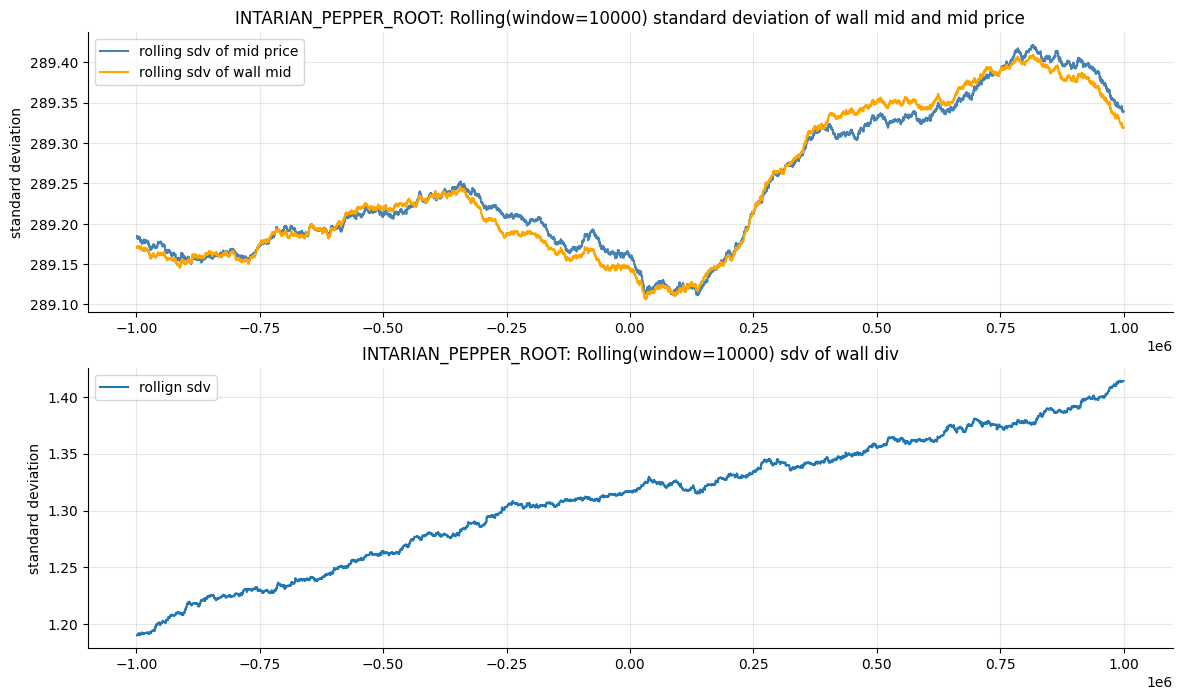

In [5]:
# plot rolling std of deviation
# compare 
rolling_std_window = 10000
for prod in PRODUCTS:
    p = prices_all[prices_all["product"]== prod]
    p["wall_div"] = p["wall_mid"] - p["mid_price"]
    p["rolling_std_wall_mid"] = p["wall_mid"].rolling(window = rolling_std_window, closed = "right").std() # concurrent
    p["rolling_std_mid_price"] = p["mid_price"].rolling(window = rolling_std_window, closed = "right").std()
    p["rolling_std_wall_div"] = p["wall_div"].rolling(window = rolling_std_window, closed = "right").std() 


    # plot rolling sdv
    fig, axes = plt.subplots(2,1, figsize = (14,8))
    axes[0].plot(p["time_index"], p["rolling_std_mid_price"], label = "rolling sdv of mid price", color = "steelblue")
    axes[0].plot(p["time_index"], p["rolling_std_wall_mid"], label = "rolling sdv of wall mid", color = "orange")
    axes[0].set_ylabel("standard deviation")
    axes[0].legend()
    axes[0].set_title(f"{prod}: Rolling(window={rolling_std_window}) standard deviation of wall mid and mid price")

    # plot rolling std for wall_div
    axes[1].plot(p["time_index"], p["rolling_std_wall_div"], label = "rollign sdv")
    axes[1].set_ylabel("standard deviation")
    axes[1].set_title(f"{prod}: Rolling(window={rolling_std_window}) sdv of wall div")
    axes[1].legend()

- Note that for `OSMIUM`, using the wall mid has consistently smaller standard deviation compared to naive mid price, implying that wall mid is more robust. We do not see this pattern for `PEPPER ROOT`. 
- On day 0, standard deviation for `OSMIUM` shoots up; expect regime shifts to a more volatile period in which spread vol increases. Maybe we could quote wider when vol increases or reduce average tolerable inventory risk when detecting vol spikes

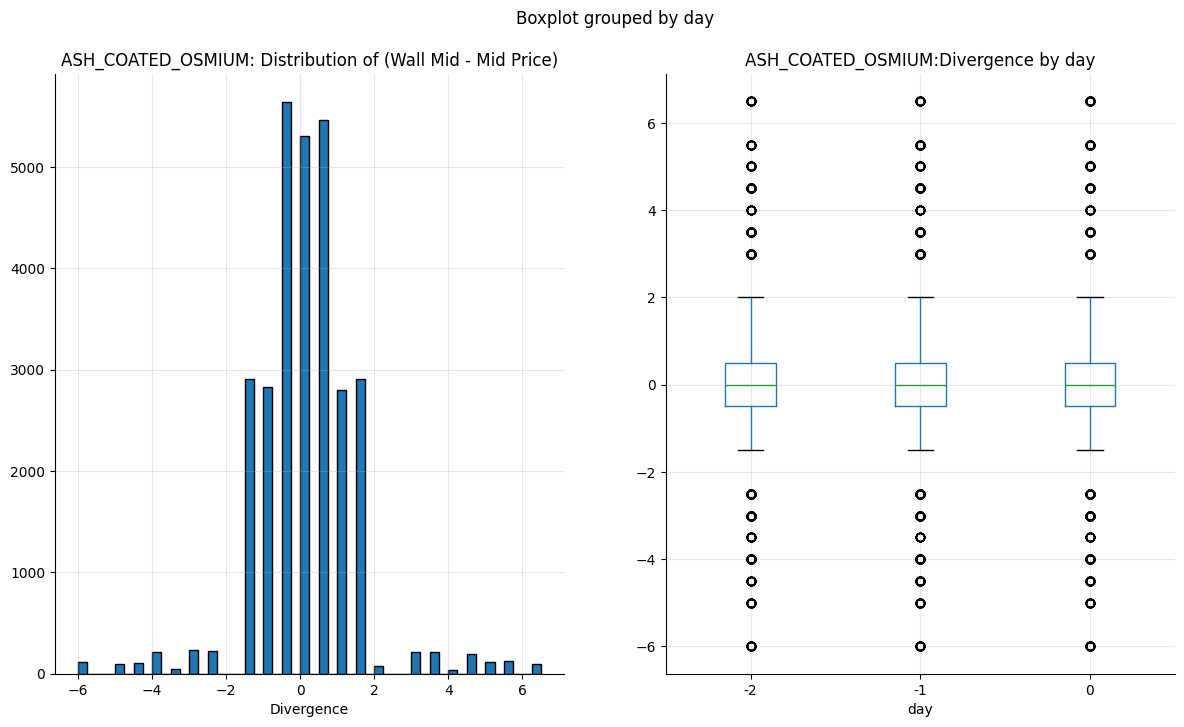

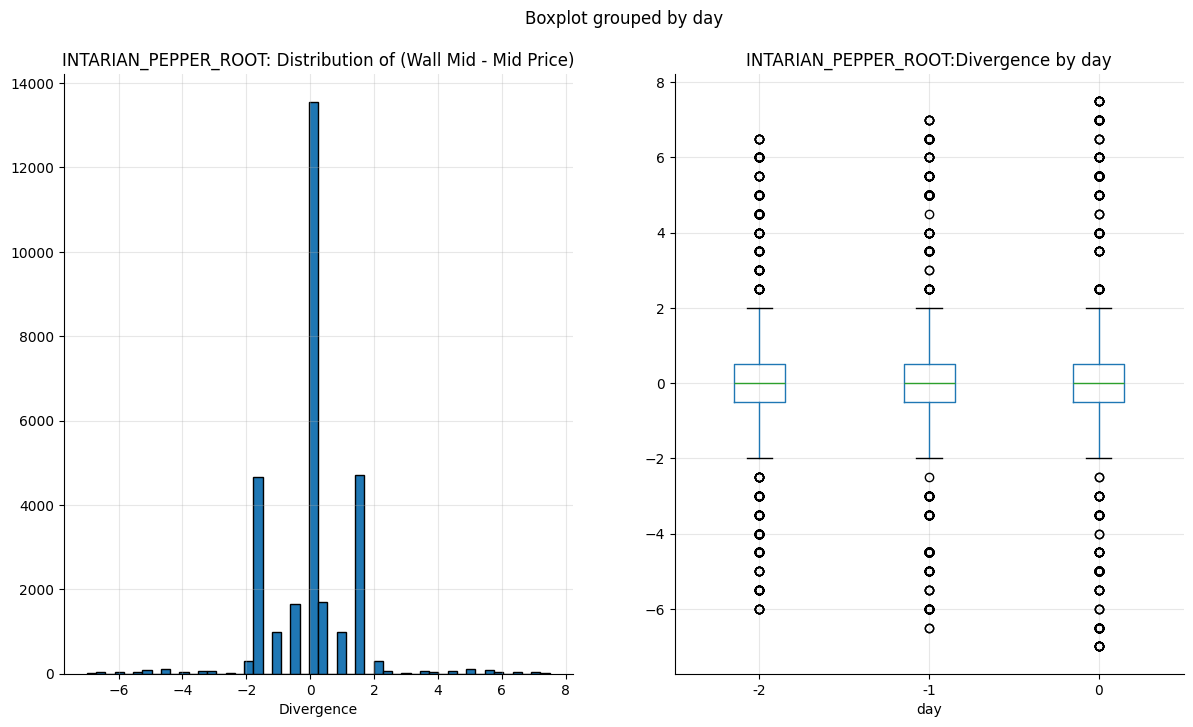

In [6]:
# distribution of divergence
# compare 
for prod in PRODUCTS:
    p = prices_all[prices_all["product"]== prod]
    p["wall_div"] = p["wall_mid"] - p["mid_price"]

    # hist
    fig, axes = plt.subplots(1,2, figsize = (14,8))
    axes[0].hist(p["wall_div"], bins = 50, edgecolor = "black")
    axes[0].set_title(f"{prod}: Distribution of (Wall Mid - Mid Price)")
    axes[0].set_xlabel("Divergence")
    
    # qqplot
    p.boxplot(column = "wall_div", by = "day", ax = axes[1])
    axes[1].set_title(f"{prod}:Divergence by day")


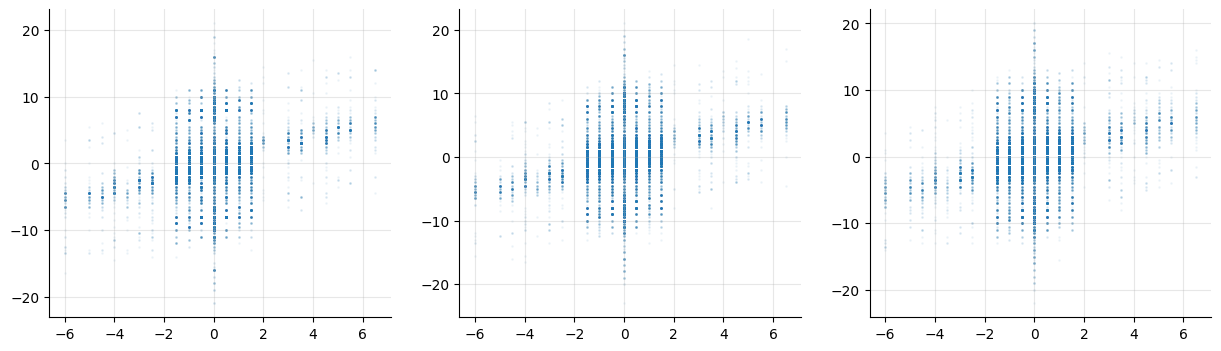

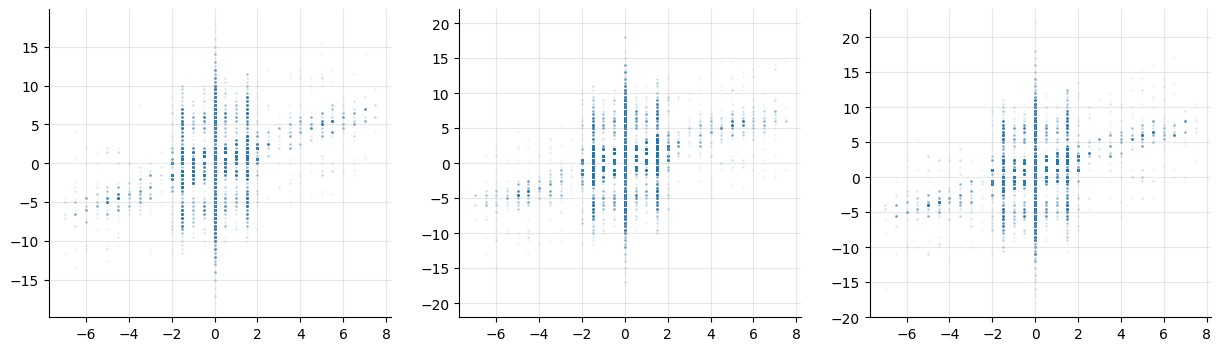

In [7]:
# predictive analysis: does wall divergence predict future mid price?

# Future mid returns over next N ticks
for prod in PRODUCTS:
    p = prices_all[prices_all["product"]== prod]
    p["wall_div"] = p["wall_mid"] - p["mid_price"]
    
    for horizon in [1, 5, 10]:
        p[f'mid_return_{horizon}'] = p['mid_price'].shift(-horizon) - p['mid_price']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for i, horizon in enumerate([1, 5, 10]):
        col = f'mid_return_{horizon}'
        valid = p[['wall_div', col]].dropna()

        axes[i].scatter(valid['wall_div'], valid[col], alpha=0.05, s=1) # s control size of dot

---
## 2. Price Overview

Plot `mid_price` across all 3 days. The shaded band shows the best bid–ask range.
We're looking for: **trending**, **mean-reverting**, or **stable** behaviour.

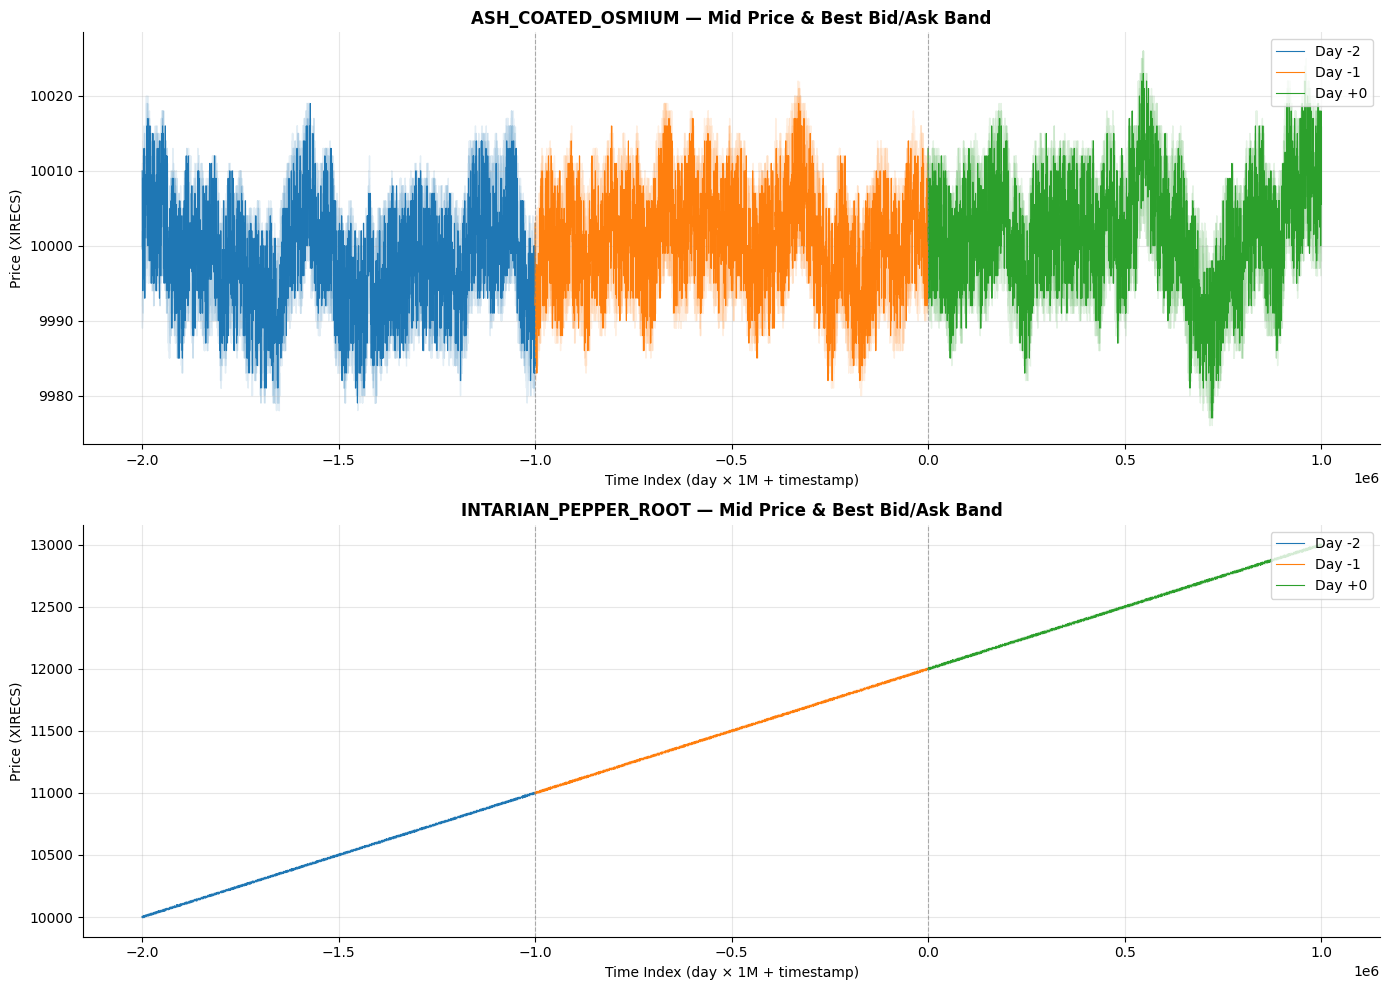

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, product in zip(axes, PRODUCTS):
    p = prices_all[prices_all['product'] == product]
    for day in DAYS:
        d = p[p['day'] == day]
        # Shaded bid-ask band
        ax.fill_between(
            d['time_index'], d['bid_price_1'], d['ask_price_1'],
            alpha=0.12, color=DAY_COLORS[day]
        )
        # Mid price line
        ax.plot(
            d['time_index'], d['mid_price'],
            color=DAY_COLORS[day], linewidth=0.8, label=f'Day {day:+d}'
        )
    # Day boundary markers
    for bday in [-1, 0]:
        ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_title(f'{product} — Mid Price & Best Bid/Ask Band', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Index (day × 1M + timestamp)')
    ax.set_ylabel('Price (XIRECS)')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [9]:
# use wall-mid

In [10]:
# Price statistics table
print(f"{'Product':<30} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>7} {'CV':>8}")
print('─' * 75)
for product in PRODUCTS:
    mp = prices_all[prices_all['product'] == product]['mid_price']
    cv = mp.std() / mp.mean()
    print(f"{product:<30} {mp.min():>8.1f} {mp.max():>8.1f} {mp.mean():>8.2f} {mp.std():>7.2f} {cv:>8.5f}")
print()
print("CV (coefficient of variation) << 1 → stable price; CV near 0 → very mean-reverting candidate")

Product                             Min      Max     Mean     Std       CV
───────────────────────────────────────────────────────────────────────────
ASH_COATED_OSMIUM                9977.0  10023.0 10000.20    5.35  0.00053
INTARIAN_PEPPER_ROOT             9998.5  13007.0 11499.89  866.11  0.07531

CV (coefficient of variation) << 1 → stable price; CV near 0 → very mean-reverting candidate


## 2.5 Finding Fair value of `ROOT`
From above graph, we can clearly see that there is a deterministic trend, implying that we should model the linear trend with respect to time.

##### Remarks
- **Why not lagged val**: It isn't a huge mistake to use lagged values, but in essence we are forcing a stochastic trend instead a deterministic trend. There are several consequences if we do this.
    - **coeffs will be close to 1**: In an AR(p) model, if we have coeffs that are close to 1, standard errors blow up, implying that our estimates our statistically unstable. 
    - **true errors are memoryless, while modeled errors persist**: A consequence of this result is that long term uncertainty explodes for our stochastic trend model while in reality variance stays constant with respect to time. That is, we will be overestimating uncertainty.


In [53]:
# Regress y on x
regression_results = []

p = prices_all[prices_all["product"]=="INTARIAN_PEPPER_ROOT"]
m = len(p) # number of rows
# set up x and y
y = p["mid_price"].to_numpy()
x = np.stack([np.ones(m),p["time_index"].to_numpy()], axis = 1)
# beta = (xtx)^-1 xty
intercept, slope = np.linalg.lstsq(x, y, rcond=None)[0]
regression_results.append({
    "product": prod,
    "slope": slope,
    "intercept": intercept
})

regression_results    

[{'product': 'INTARIAN_PEPPER_ROOT',
  'slope': np.float64(0.0010000053828369926),
  'intercept': np.float64(11999.998611317887)}]

- Round with slope = 0.001, intercept = 12000
- Make sure to code trader class such that at first iteration we reverse engineer the the time_index before passing it to the linear equation.

---
## 3. Spread Analysis

`spread = ask_price_1 - bid_price_1`  
A **tight, stable spread (= 1 tick most of the time)** is the hallmark of a market-making opportunity — we can earn the spread by posting both sides.

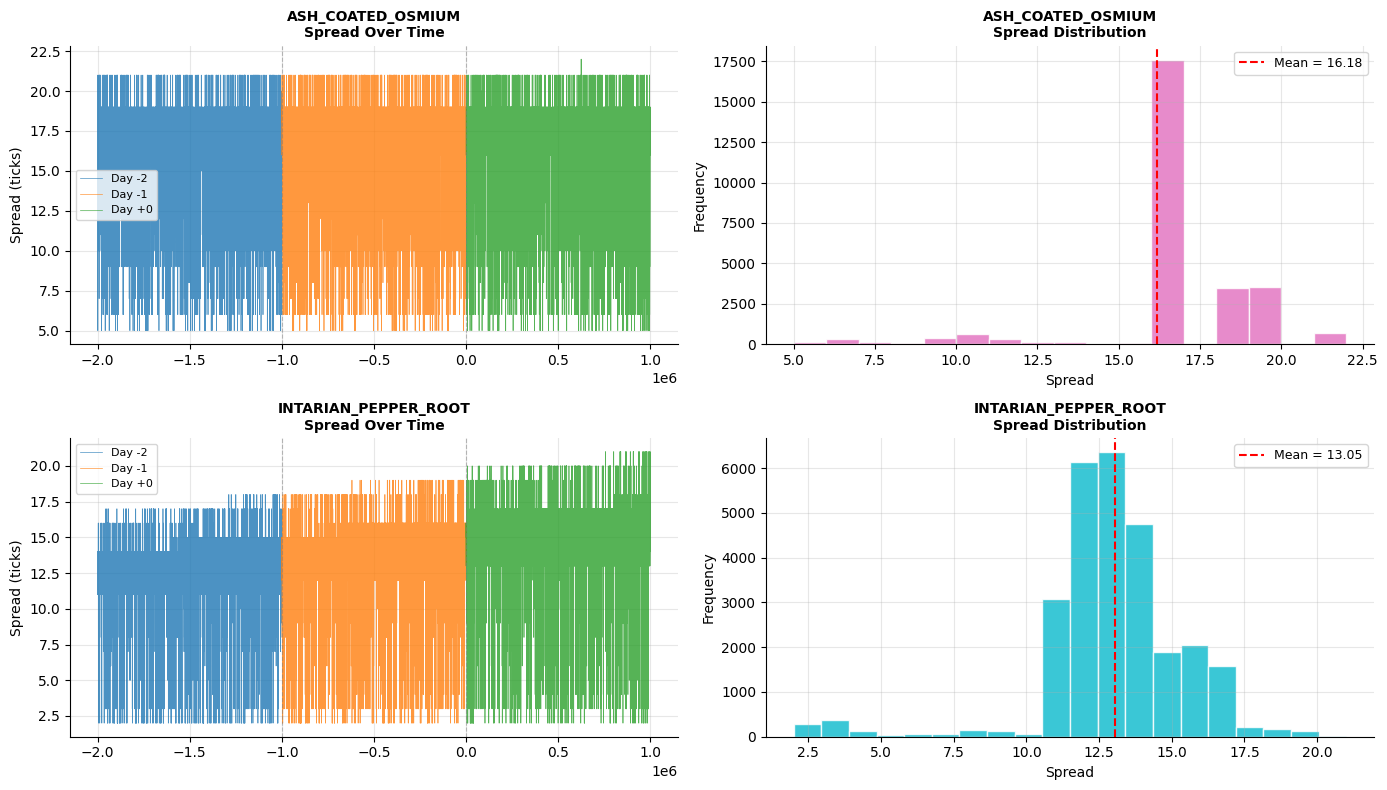


Product                         Mean Sprd   % == 1   % == 2    Max
────────────────────────────────────────────────────────────────────
ASH_COATED_OSMIUM                  16.175     0.0%     0.0%     22
INTARIAN_PEPPER_ROOT               13.047     0.0%     1.0%     21


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, product in enumerate(PRODUCTS):
    p = prices_all[prices_all['product'] == product].copy()
    p['spread'] = p['ask_price_1'] - p['bid_price_1']
    p_spread = p.dropna(subset=['spread'])

    # Time series
    ax = axes[row, 0]
    for day in DAYS:
        d = p_spread[p_spread['day'] == day]
        ax.plot(d['time_index'], d['spread'], color=DAY_COLORS[day],
                linewidth=0.5, alpha=0.8, label=f'Day {day:+d}')
    for bday in [-1, 0]:
        ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{product}\nSpread Over Time', fontsize=10, fontweight='bold')
    ax.set_ylabel('Spread (ticks)')
    ax.legend(fontsize=8)

    # Histogram
    ax = axes[row, 1]
    spread_vals = p_spread['spread']
    unique_spreads = sorted(spread_vals.unique())
    ax.hist(spread_vals, bins=max(len(unique_spreads), 10), edgecolor='white',
            color=PROD_COLORS[product], alpha=0.85)
    ax.axvline(spread_vals.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {spread_vals.mean():.2f}')
    ax.set_title(f'{product}\nSpread Distribution', fontsize=10, fontweight='bold')
    ax.set_xlabel('Spread')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Spread summary
print(f"\n{'Product':<30} {'Mean Sprd':>10} {'% == 1':>8} {'% == 2':>8} {'Max':>6}")
print('─' * 68)
for product in PRODUCTS:
    p = prices_all[prices_all['product'] == product].copy()
    p['spread'] = p['ask_price_1'] - p['bid_price_1']
    s = p['spread'].dropna()
    print(f"{product:<30} {s.mean():>10.3f} {(s == 1).mean() * 100:>7.1f}% {(s == 2).mean() * 100:>7.1f}% {s.max():>6.0f}")

---
## 4. Order Book Depth

Total depth = sum of volumes across all 3 price levels.  
**Imbalance** = `(bid_depth − ask_depth) / (bid_depth + ask_depth)` — positive means more buy-side pressure; negative means more sell-side pressure.

If rolling imbalance leads mid-price moves → useful signal for directional orders.

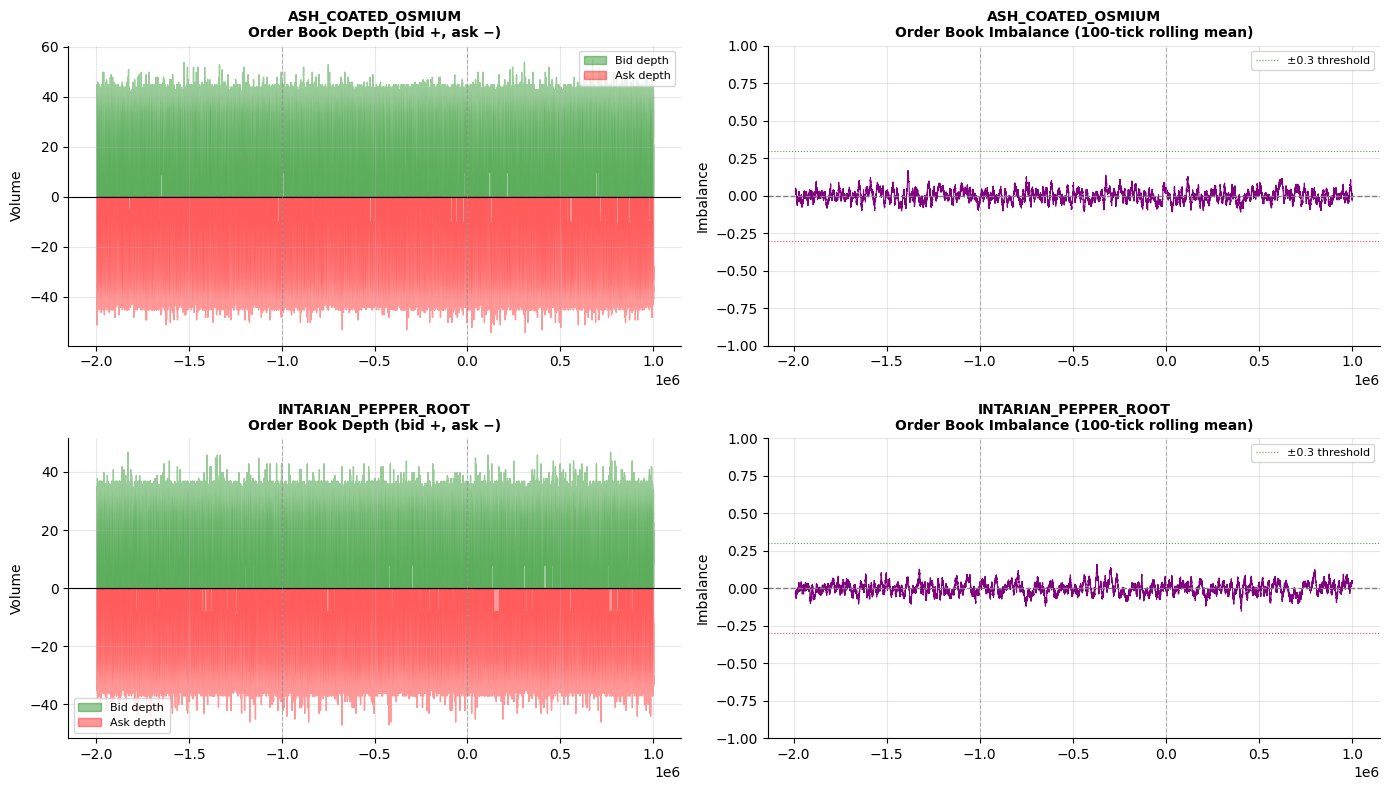


Product                         Avg Bid Depth  Avg Ask Depth  Avg Imbalance
────────────────────────────────────────────────────────────────────────────
ASH_COATED_OSMIUM                        30.2           30.2        -0.0014
INTARIAN_PEPPER_ROOT                     24.2           24.3        -0.0031


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, product in enumerate(PRODUCTS):
    p = prices_all[prices_all['product'] == product].copy()
    p['bid_depth'] = p[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].sum(axis=1)
    p['ask_depth'] = p[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].sum(axis=1)
    total = p['bid_depth'] + p['ask_depth']
    p['imbalance'] = np.where(total > 0, (p['bid_depth'] - p['ask_depth']) / total, np.nan)

    # Depth over time
    ax = axes[row, 0]
    ax.fill_between(p['time_index'], 0, p['bid_depth'], alpha=0.4, color='green', label='Bid depth')
    ax.fill_between(p['time_index'], 0, -p['ask_depth'], alpha=0.4, color='red', label='Ask depth')
    ax.axhline(0, color='black', linewidth=0.8)
    for bday in [-1, 0]:
        ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{product}\nOrder Book Depth (bid +, ask −)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Volume')
    ax.legend(fontsize=8)

    # Rolling imbalance
    ax = axes[row, 1]
    rolling_imb = p.set_index('time_index')['imbalance'].rolling(100).mean()
    ax.plot(rolling_imb.index, rolling_imb.values, color='purple', linewidth=0.8)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.axhline(0.3, color='green', linestyle=':', linewidth=0.8, alpha=0.7, label='±0.3 threshold')
    ax.axhline(-0.3, color='red', linestyle=':', linewidth=0.8, alpha=0.7)
    for bday in [-1, 0]:
        ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{product}\nOrder Book Imbalance (100-tick rolling mean)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Imbalance')
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Depth stats
print(f"\n{'Product':<30} {'Avg Bid Depth':>14} {'Avg Ask Depth':>14} {'Avg Imbalance':>14}")
print('─' * 76)
for product in PRODUCTS:
    p = prices_all[prices_all['product'] == product].copy()
    p['bid_depth'] = p[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].sum(axis=1)
    p['ask_depth'] = p[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].sum(axis=1)
    total = p['bid_depth'] + p['ask_depth']
    p['imbalance'] = np.where(total > 0, (p['bid_depth'] - p['ask_depth']) / total, np.nan)
    print(f"{product:<30} {p['bid_depth'].mean():>14.1f} {p['ask_depth'].mean():>14.1f} {p['imbalance'].mean():>14.4f}")

---
## 5. Trade Flow

Trade-level analysis: price, quantity distribution, and VWAP vs mid-price comparison.

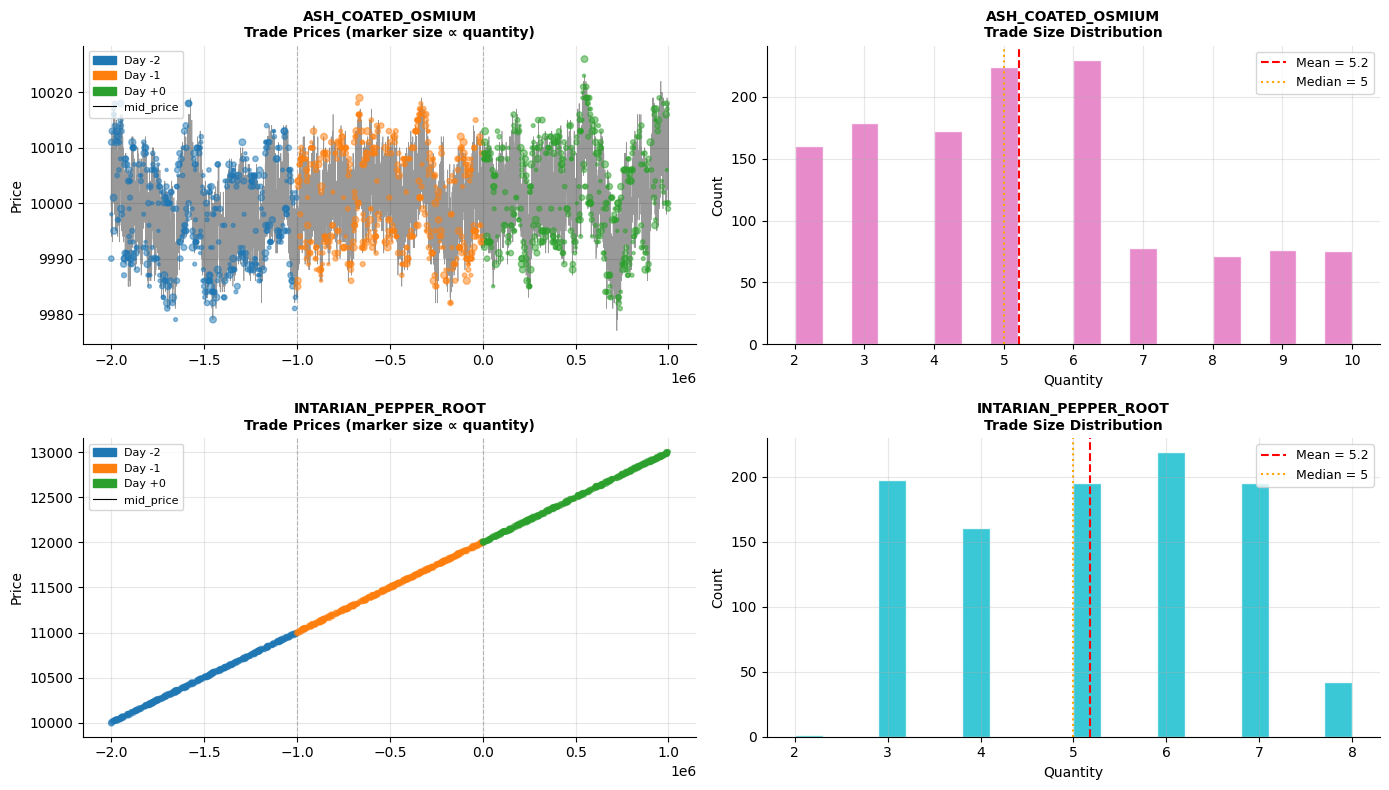

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, product in enumerate(PRODUCTS):
    t = trades_all[trades_all['symbol'] == product].copy()
    p = prices_all[prices_all['product'] == product]

    # Scatter: trade prices over time (size ∝ quantity)
    ax = axes[row, 0]
    colors = [DAY_COLORS[d] for d in t['day']]
    ax.scatter(t['time_index'], t['price'], s=t['quantity'] * 2.5,
               c=colors, alpha=0.5, zorder=3, label='Trade')
    ax.plot(p['time_index'], p['mid_price'], color='black',
            linewidth=0.5, alpha=0.4, label='mid_price')
    for bday in [-1, 0]:
        ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    handles = [mpatches.Patch(color=DAY_COLORS[d], label=f'Day {d:+d}') for d in DAYS]
    handles.append(plt.Line2D([0], [0], color='black', linewidth=0.8, label='mid_price'))
    ax.legend(handles=handles, fontsize=8)
    ax.set_title(f'{product}\nTrade Prices (marker size ∝ quantity)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Price')

    # Trade size distribution
    ax = axes[row, 1]
    ax.hist(t['quantity'], bins=20, edgecolor='white',
            color=PROD_COLORS[product], alpha=0.85)
    ax.axvline(t['quantity'].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f"Mean = {t['quantity'].mean():.1f}")
    ax.axvline(t['quantity'].median(), color='orange', linestyle=':', linewidth=1.5,
               label=f"Median = {t['quantity'].median():.0f}")
    ax.set_title(f'{product}\nTrade Size Distribution', fontsize=10, fontweight='bold')
    ax.set_xlabel('Quantity')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
# VWAP vs mean mid_price by day
print("VWAP vs Mean Mid-Price by Day")
print(f"{'Product':<30} {'Day':>5} {'VWAP':>10} {'Mean Mid':>10} {'Diff':>8} {'# Trades':>10}")
print('─' * 78)
for product in PRODUCTS:
    t = trades_all[trades_all['symbol'] == product]
    p = prices_all[prices_all['product'] == product]
    for day in DAYS:
        td = t[t['day'] == day]
        pd_day = p[p['day'] == day]
        if len(td) > 0:
            vwap = (td['price'] * td['quantity']).sum() / td['quantity'].sum()
            mid_mean = pd_day['mid_price'].mean()
            diff = vwap - mid_mean
            print(f"{product:<30} {day:>+5} {vwap:>10.2f} {mid_mean:>10.2f} {diff:>+8.2f} {len(td):>10,}")
    print()

VWAP vs Mean Mid-Price by Day
Product                          Day       VWAP   Mean Mid     Diff   # Trades
──────────────────────────────────────────────────────────────────────────────
ASH_COATED_OSMIUM                 -2    9998.26    9998.17    +0.09        429
ASH_COATED_OSMIUM                 -1   10000.85   10000.83    +0.01        425
ASH_COATED_OSMIUM                 +0   10001.64   10001.61    +0.04        411

INTARIAN_PEPPER_ROOT              -2   10490.48   10499.96    -9.48        344
INTARIAN_PEPPER_ROOT              -1   11496.66   11500.03    -3.37        335
INTARIAN_PEPPER_ROOT              +0   12519.79   12500.17   +19.62        332



---
## 6. Fair Value Estimation

Two candidate fair-value estimates:
- **Rolling mid** (50-tick window): smoothed reference price from the order book  
- **Residual autocorrelation**: lag-1 AC of `(mid − rolling_mid)` — negative AC signals mean-reversion (price overshoots and corrects)

The residual analysis tells us whether simply quoting ±1 around a rolling mid will be profitable.

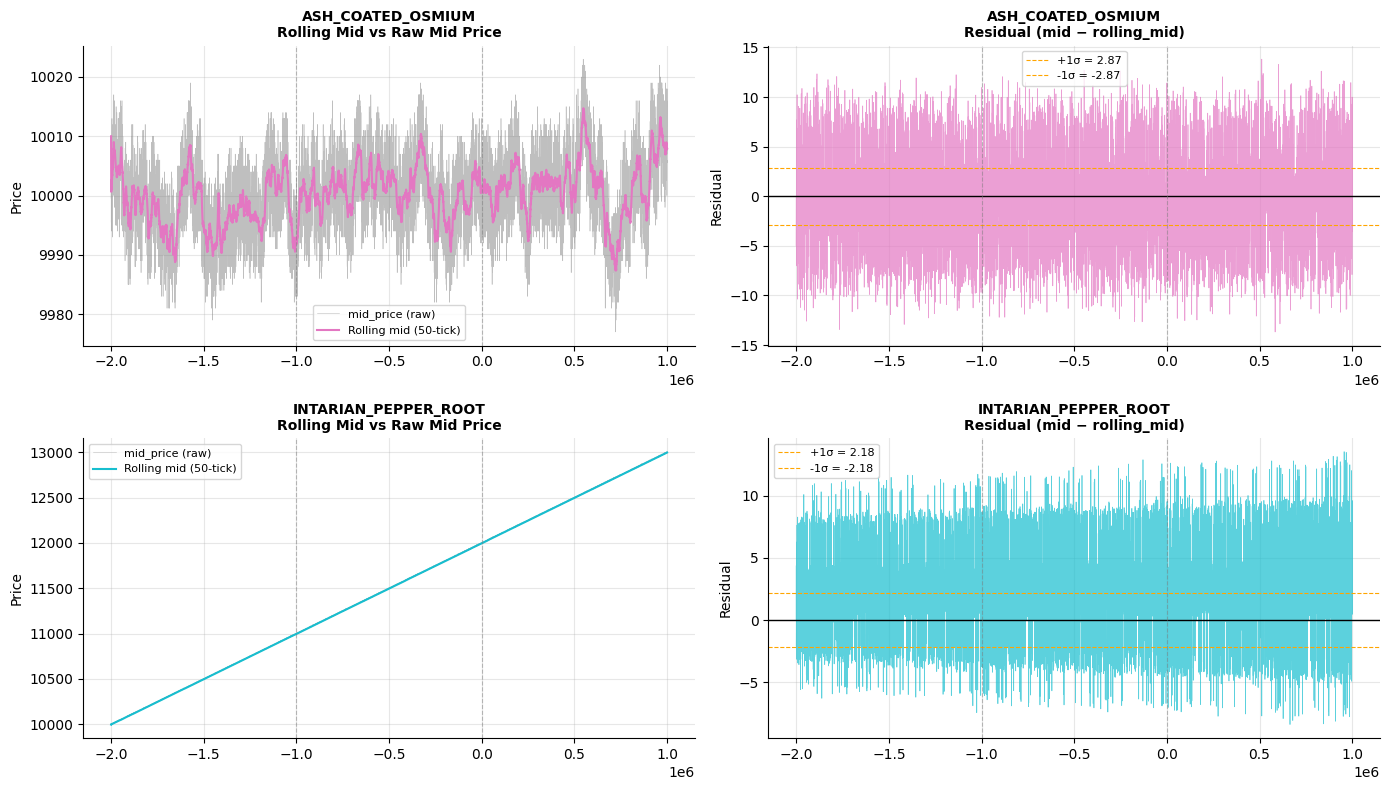

Residual Mean-Reversion Test (lag-1 autocorrelation of mid − rolling_mid)

  AC < −0.1 → mean-reverting (price corrects after overshoots)
  AC > +0.1 → momentum (price continues in direction)
  AC ≈  0   → random walk

Product                          AC (lag-1)         Interpretation
────────────────────────────────────────────────────────────────────
ASH_COATED_OSMIUM                    0.1740               momentum
INTARIAN_PEPPER_ROOT                 0.0076            random walk


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, product in enumerate(PRODUCTS):
    p = prices_all[prices_all['product'] == product].copy().sort_values('time_index')
    p['rolling_mid'] = p['mid_price'].rolling(50, min_periods=1).mean()
    p['residual'] = p['mid_price'] - p['rolling_mid']

    # Rolling mid vs raw mid_price
    ax = axes[row, 0]
    ax.plot(p['time_index'], p['mid_price'], color='gray',
            linewidth=0.4, alpha=0.5, label='mid_price (raw)')
    ax.plot(p['time_index'], p['rolling_mid'], color=PROD_COLORS[product],
            linewidth=1.5, label='Rolling mid (50-tick)')
    for bday in [-1, 0]:
        ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{product}\nRolling Mid vs Raw Mid Price', fontsize=10, fontweight='bold')
    ax.set_ylabel('Price')
    ax.legend(fontsize=8)

    # Residuals
    ax = axes[row, 1]
    ax.plot(p['time_index'], p['residual'], color=PROD_COLORS[product],
            linewidth=0.5, alpha=0.7)
    ax.axhline(0, color='black', linewidth=1)
    ax.axhline(p['residual'].std(), color='orange', linestyle='--',
               linewidth=0.8, label=f'+1σ = {p["residual"].std():.2f}')
    ax.axhline(-p['residual'].std(), color='orange', linestyle='--',
               linewidth=0.8, label=f'-1σ = {-p["residual"].std():.2f}')
    for bday in [-1, 0]:
        ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{product}\nResidual (mid − rolling_mid)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Residual')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Autocorrelation of residuals
print("Residual Mean-Reversion Test (lag-1 autocorrelation of mid − rolling_mid)")
print(f"\n  AC < −0.1 → mean-reverting (price corrects after overshoots)")
print(f"  AC > +0.1 → momentum (price continues in direction)")
print(f"  AC ≈  0   → random walk")
print()
print(f"{'Product':<30} {'AC (lag-1)':>12} {'Interpretation':>22}")
print('─' * 68)
for product in PRODUCTS:
    p = prices_all[prices_all['product'] == product].copy().sort_values('time_index')
    p['rolling_mid'] = p['mid_price'].rolling(50, min_periods=1).mean()
    resid = (p['mid_price'] - p['rolling_mid']).dropna()
    ac = resid.autocorr(lag=1)
    interp = 'mean-reverting' if ac < -0.1 else ('momentum' if ac > 0.1 else 'random walk')
    print(f"{product:<30} {ac:>12.4f} {interp:>22}")

---
## 7. Cumulative PnL Review

The `profit_and_loss` column is the **cumulative PnL** of each product across the simulation. This shows what edge direction was profitable and how stable the earnings were over time.

In [17]:
prices_all

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,time_index,wall_mid
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,0.0,NaN,0.0,10005.0,9.0,10008.0,17.0,NaN,0.0,9998.5,0.0,-2000000,10000.0
1,-2,0,ASH_COATED_OSMIUM,NaN,0.0,NaN,0.0,NaN,0.0,10010.0,25.0,NaN,0.0,NaN,0.0,10010.0,0.0,-2000000,10010.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,0.0,10006.0,11.0,10008.0,16.0,NaN,0.0,10000.5,0.0,-1999900,10000.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,0.0,NaN,0.0,10008.0,15.0,10011.0,20.0,NaN,0.0,10000.0,0.0,-1999900,10001.5
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,0.0,NaN,0.0,10008.0,20.0,NaN,0.0,NaN,0.0,10001.5,0.0,-1999800,10001.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,999700,INTARIAN_PEPPER_ROOT,12989.0,20.0,NaN,0.0,NaN,0.0,13007.0,10.0,13010.0,20.0,NaN,0.0,12998.0,0.0,999700,12999.5
59996,0,999800,INTARIAN_PEPPER_ROOT,NaN,0.0,NaN,0.0,NaN,0.0,13007.0,10.0,13010.0,24.0,NaN,0.0,13007.0,0.0,999800,13007.0
59997,0,999800,ASH_COATED_OSMIUM,NaN,0.0,NaN,0.0,NaN,0.0,10018.0,27.0,NaN,0.0,NaN,0.0,10018.0,0.0,999800,10018.0
59998,0,999900,ASH_COATED_OSMIUM,9998.0,21.0,NaN,0.0,NaN,0.0,10016.0,12.0,10019.0,21.0,NaN,0.0,10007.0,0.0,999900,10008.5


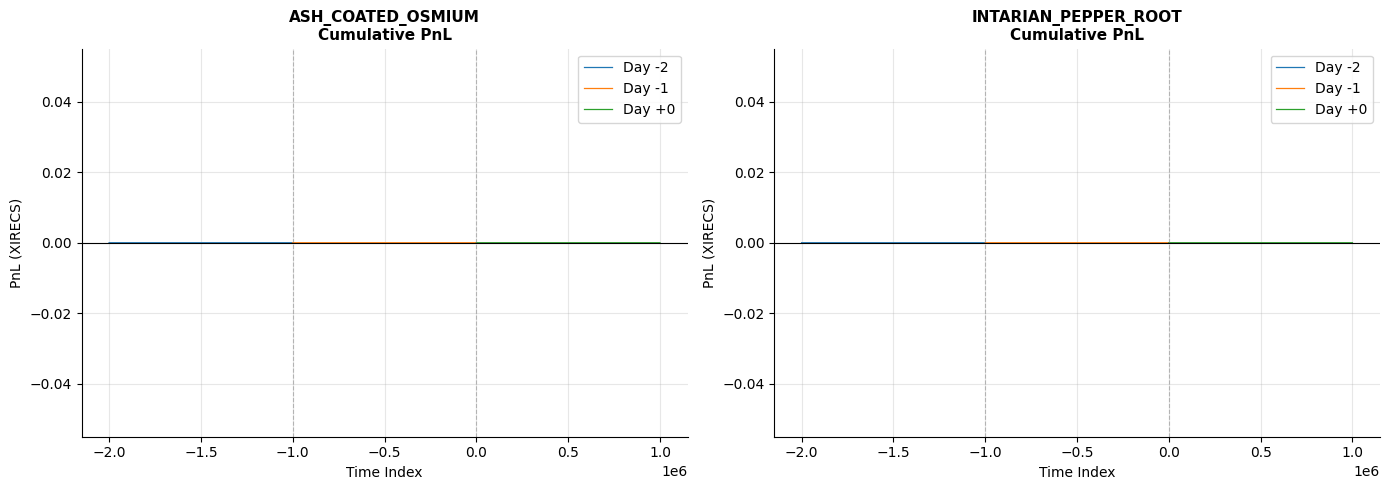

Final cumulative PnL per day:
Product                            Day -2     Day -1      Day 0
─────────────────────────────────────────────────────────────────
ASH_COATED_OSMIUM                    +0.0      +0.0      +0.0
INTARIAN_PEPPER_ROOT                 +0.0      +0.0      +0.0


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, product in zip(axes, PRODUCTS):
    p = prices_all[prices_all['product'] == product]
    for day in DAYS:
        d = p[p['day'] == day].sort_values('time_index')
        ax.plot(d['time_index'], d['profit_and_loss'],
                color=DAY_COLORS[day], linewidth=0.9, label=f'Day {day:+d}')
    for bday in [-1, 0]:
        ax.axvline(bday * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{product}\nCumulative PnL', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time Index')
    ax.set_ylabel('PnL (XIRECS)')
    ax.legend()

plt.tight_layout()
plt.show()

# Final PnL per product per day
print("Final cumulative PnL per day:")
print(f"{'Product':<30} {'Day -2':>10} {'Day -1':>10} {'Day 0':>10}")
print('─' * 65)
for product in PRODUCTS:
    p = prices_all[prices_all['product'] == product]
    row = product
    vals = []
    for day in DAYS:
        d = p[p['day'] == day].sort_values('timestamp')
        vals.append(f"{d['profit_and_loss'].iloc[-1]:>+10.1f}" if len(d) > 0 else f"{'N/A':>10}")
    print(f"{product:<30} {''.join(vals)}")

---
## 8. Summary Report

In [19]:
print("=" * 72)
print("  ROUND 1 EDA — KEY STATISTICS SUMMARY")
print("=" * 72)

for product in PRODUCTS:
    p = prices_all[prices_all['product'] == product].copy()
    t = trades_all[trades_all['symbol'] == product].copy()

    p['spread']    = p['ask_price_1'] - p['bid_price_1']
    p['bid_depth'] = p[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].sum(axis=1)
    p['ask_depth'] = p[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].sum(axis=1)
    total          = p['bid_depth'] + p['ask_depth']
    p['imbalance'] = np.where(total > 0, (p['bid_depth'] - p['ask_depth']) / total, np.nan)

    p_sorted = p.sort_values('time_index')
    p_sorted['rolling_mid'] = p_sorted['mid_price'].rolling(50, min_periods=1).mean()
    resid = (p_sorted['mid_price'] - p_sorted['rolling_mid']).dropna()
    ac = resid.autocorr(lag=1)
    interp = 'mean-reverting' if ac < -0.1 else ('momentum' if ac > 0.1 else 'random walk')

    s = p['spread'].dropna()
    vwap_all = (t['price'] * t['quantity']).sum() / t['quantity'].sum() if len(t) > 0 else float('nan')
    final_pnl = p[p['day'] == 0].sort_values('timestamp')['profit_and_loss'].iloc[-1] if len(p[p['day'] == 0]) > 0 else float('nan')

    print(f"\n{'─' * 72}")
    print(f"  PRODUCT : {product}")
    print(f"{'─' * 72}")
    print(f"  Price range     : {p['mid_price'].min():.1f} – {p['mid_price'].max():.1f}")
    print(f"  Mean ± Std      : {p['mid_price'].mean():.2f} ± {p['mid_price'].std():.2f}")
    print(f"  CV (std/mean)   : {p['mid_price'].std() / p['mid_price'].mean():.5f}")
    print(f"  Residual AC-1   : {ac:.4f}  → {interp}")
    print(f"  Mean spread     : {s.mean():.3f} ticks")
    print(f"  % spread == 1   : {(s == 1).mean() * 100:.1f}%")
    print(f"  Max spread      : {s.max():.0f} ticks")
    print(f"  Avg bid depth   : {p['bid_depth'].mean():.1f}")
    print(f"  Avg ask depth   : {p['ask_depth'].mean():.1f}")
    print(f"  Mean OB imbal.  : {p['imbalance'].mean():.4f}")
    print(f"  Total trades    : {len(t):,}")
    print(f"  Avg trade size  : {t['quantity'].mean():.1f}" if len(t) > 0 else "  Avg trade size  : N/A")
    print(f"  Overall VWAP    : {vwap_all:.2f}")
    print(f"  Final PnL Day 0 : {final_pnl:+.1f} XIRECS")

print(f"\n{'=' * 72}")

  ROUND 1 EDA — KEY STATISTICS SUMMARY

────────────────────────────────────────────────────────────────────────
  PRODUCT : ASH_COATED_OSMIUM
────────────────────────────────────────────────────────────────────────
  Price range     : 9977.0 – 10023.0
  Mean ± Std      : 10000.20 ± 5.35
  CV (std/mean)   : 0.00053
  Residual AC-1   : 0.1740  → momentum
  Mean spread     : 16.175 ticks
  % spread == 1   : 0.0%
  Max spread      : 22 ticks
  Avg bid depth   : 30.2
  Avg ask depth   : 30.2
  Mean OB imbal.  : -0.0014
  Total trades    : 1,265
  Avg trade size  : 5.2
  Overall VWAP    : 10000.24
  Final PnL Day 0 : +0.0 XIRECS

────────────────────────────────────────────────────────────────────────
  PRODUCT : INTARIAN_PEPPER_ROOT
────────────────────────────────────────────────────────────────────────
  Price range     : 9998.5 – 13007.0
  Mean ± Std      : 11499.89 ± 866.11
  CV (std/mean)   : 0.07531
  Residual AC-1   : 0.0076  → random walk
  Mean spread     : 13.047 ticks
  % spread

---
## Strategic Recommendations

> **How to read this section:** each recommendation is conditioned on what the stats above revealed. Cross-reference the numbers printed in the summary before acting on any suggestion.

---

### General Framework

| Observation | Implication |
|---|---|
| Spread mostly = 1 tick | **Market-make**: post a buy 1 below fair value, sell 1 above — earn the spread |
| Residual AC-1 << 0 (mean-reverting) | **Aggressive fills**: hit bots hard when they mis-price; price will revert to fair value |
| Residual AC-1 >> 0 (momentum) | **Directional**: when imbalance signals a direction, lean your position that way |
| Stable CV (< 0.001) | Price is tightly anchored — use a **static fair value** (e.g., fixed mean) |
| Volatile CV or drifting PnL | Use **adaptive fair value** (rolling mid or VWAP) |

---

### Per-Product Action Items

#### `ASH_COATED_OSMIUM`
- **Fair value formula**: Start with `rolling_mid_50` (50-tick rolling mean of `mid_price`). If mean-reversion is confirmed, this is your `acceptable_price`.
- **Strategy**: If spread is mostly 1 tick → pure market-making. Place a buy order at `fair_value - 1` and a sell at `fair_value + 1`, sized to stay within position limits.
- **Position management**: Track running position carefully; this product may have one-sided order book moments (bid_price_1 NaN). Skip orders for that iteration rather than erroring.
- **State to persist**: Last 50 `mid_price` values (list, jsonpickle) for rolling average.

#### `INTARIAN_PEPPER_ROOT`
- **Fair value formula**: Same starting point — `rolling_mid_50`. Compare to VWAP to see which tracks better.
- **Strategy**: If spread behaviour matches ASH, apply same market-making. If OB imbalance is consistently non-zero, layer in an **imbalance tilt**: shift your quotes by 1 tick in the direction of excess supply/demand.
- **State to persist**: Last 50 mid prices + running VWAP numerator/denominator (lightweight — avoids storing full trade history).

---

### Next Steps Checklist

1. **Confirm position limits** for both products on the Prosperity platform (typically ±20). Hard-code per-product limits in `trader.py`.
2. **Write `trader.py`** with the skeleton from `docs/WORKFLOW.md`. Implement market-making first (it's the safer baseline).
3. **Handle one-sided book** gracefully: use `state.order_depths[product].sell_orders` only if non-empty, and same for `buy_orders`. Skip or use mid_price from prior tick (via `traderData`) when one side is absent.
4. **Backtest mentally** using the EDA data: for each timestamp, would your `fair_value` beat the best available prices? Would you have hit position limits?
5. **Test locally** using `round1/test_trader.py` (see `docs/WORKFLOW.md` for template). Verify no exceptions and `traderData` length < 50,000 chars.
6. **Submit** `round1/trader.py` to Prosperity; save the UUID in a comment at the top of the file.

---

### `trader.py` Fair Value Snippet

```python
# In run(), per product:
if state.traderData:
    saved = jsonpickle.decode(state.traderData)
else:
    saved = {'price_history': {}}

for product in state.order_depths:
    od = state.order_depths[product]
    
    # Update rolling price history
    hist = saved['price_history'].get(product, [])
    if od.buy_orders and od.sell_orders:
        best_bid = max(od.buy_orders)
        best_ask = min(od.sell_orders)
        mid = (best_bid + best_ask) / 2
        hist.append(mid)
    if len(hist) > 50:
        hist = hist[-50:]          # keep only last 50
    saved['price_history'][product] = hist
    
    fair_value = sum(hist) / len(hist) if hist else None
    if fair_value is None:
        continue                   # no data yet, skip
    
    # ... order sizing logic using fair_value ...
```